# *Electric Vehicle Charging Demand Dataset*  
Kelompok  3:  
Rr. Tyas Anandyta Susanto (5027261035)  
Arnand Nabiel Zakia (5027261074)  
Muhammad Athar Ghaisan (5027261105)  
SMART CITY

Perkembangan kendaraan listrik dalam konsep smart city membutuhkan sistem pengisian daya yang efisien agar kebutuhan energi dapat dipenuhi dengan baik. Data pengisian kendaraan listrik menarik untuk dianalisis karena terdapat berbagai faktor seperti kepadatan lalu lintas, kapasitas baterai, daya pengisian, lama pengisian, dan energi yang digunakan. Dengan statistik deskriptif, kita dapat melihat gambaran umum pola kebutuhan pengisian kendaraan listrik serta mengetahui seberapa besar variasi dari faktor-faktor tersebut.  
1. Berapa rata-rata energi yang digunakan untuk mengisi kendaraan listrik?  
2. Berapa rata-rata waktu tunggu kendaraan sebelum melakukan pengisian?  
3. Bagaimana kondisi lalu lintas yang paling sering terjadi saat kendaraan melakukan pengisian?  

In [3]:
import pandas as pd

df = pd.read_csv("ev_charging_dataset.csv")
print(df.shape)   # (200, 27)
df[['energy_consumed_kWh', 'charging_duration', 'waiting_time', 'battery_capacity_kWh', 'traffic_density']].head(200)

ImportError: Unable to import required dependency numpy. Please see the traceback for details.

setiap baris mewakili satu sesi pengisian kendaraan listrik

| Kolom | Arti | Jenis variabel | Skala | Satuan | Contoh |
| :--- | :--- | :--- | :--- | :--- | :--- |
| energy_consumed_kWh | Jumlah energi listrik yang digunakan kendaraan selama satu sesi pengisian | Kuantitatif kontinu | Rasio | kWh | 35.5 kWh |
| charging_duration| Lama waktu yang dibutuhkan kendaraan untuk melakukan pengisian daya sampai selesai | Kuantitatif kontinu | Rasio | Menit | 45 menit |
| waiting_time | Waktu yang dihabiskan kendaraan untuk menunggu sebelum proses pengisian dimulai | Kuantitatif kontinu | Rasio | Menit | 10 Menit |
| battery_capacity_kWh |Kapasitas total baterai yang dimiliki kendaraan listrik | Kuantitatif kontinu | Rasio |  kWh | 60 Kwh |
| traffic_density | Kondisi kepadatan lalu lintas ketika kendaraan melakukan pengisian daya | Kualitatif | Ordinal |  Low, Medium, High | High

In [ ]:
df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   str    
 1   station_id              8354 non-null   str    
 2   location_type           8354 non-null   str    
 3   vehicle_id              8354 non-null   str    
 4   vehicle_type            8354 non-null   str    
 5   arrival_time            8354 non-null   str    
 6   charging_start_time     8354 non-null   str    
 7   charging_end_time       8354 non-null   str    
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   float64
 15

np.int64(0)

In [ ]:
kolom1 = df["energy_consumed_kWh"].head(200)
kolom1.mean(), kolom1.median(), kolom1.mode()[0]
kolom1.var(), kolom1.std()
kolom1.quantile(0.25), kolom1.quantile(0.75)

kolom2 = df["charging_duration"].head(200)
kolom2.mean(), kolom2.median(), kolom2.mode()[0]
kolom2.var(), kolom2.std()
kolom2.quantile(0.25), kolom2.quantile(0.75)

kolom3 = df["waiting_time"].head(200)
kolom3.mean(), kolom3.median(), kolom3.mode()[0]
kolom3.var(), kolom3.std()
kolom3.quantile(0.25), kolom3.quantile(0.75)

kolom3 = df["battery_capacity_kWh"].head(200)
kolom3.mean(), kolom3.median(), kolom3.mode()[0]
kolom3.var(), kolom3.std()
kolom3.quantile(0.25), kolom3.quantile(0.75)

df[["energy_consumed_kWh", "charging_duration", "waiting_time", "battery_capacity_kWh"]].head(200).describe()

,energy_consumed_kWh,charging_duration,waiting_time,battery_capacity_kWh
count,200.000000,200.000000,200.00000,200.000000
mean,38.421289,181.792141,10.22000,59.350000
std,19.878524,161.576915,4.65294,24.414295
min,11.178683,14.677128,0.00000,30.000000
25%,22.372480,60.606758,7.00000,40.000000
50%,34.730097,135.525904,10.00000,60.000000
75%,51.537540,258.987917,13.00000,75.000000
max,89.438047,766.611830,22.00000,100.000000


In [ ]:
df["traffic_density"].value_counts()
df["traffic_density"].value_counts(normalize=True) * 100

traffic_density
Low       37.514963
High      37.491022
Medium    24.994015
Name: proportion, dtype: float64

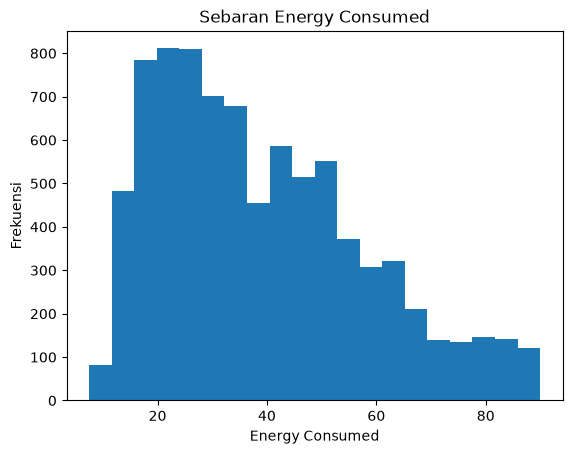

Interpretasi: Grafik menunjukkan distribusi jumlah energi yang digunakan oleh kendaraan listrik selama proses pengisian.
Semakin tinggi frekuensi pada suatu rentang, semakin banyak kendaraan yang menggunakan energi pada rentang tersebut.


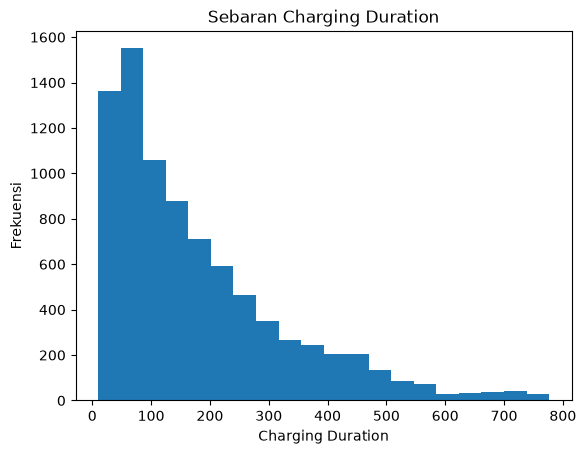

Interpretasi: Grafik menunjukkan distribusi lama waktu yang dibutuhkan kendaraan untuk melakukan pengisian.
Rentang dengan frekuensi tertinggi menunjukkan durasi pengisian yang paling sering terjadi.


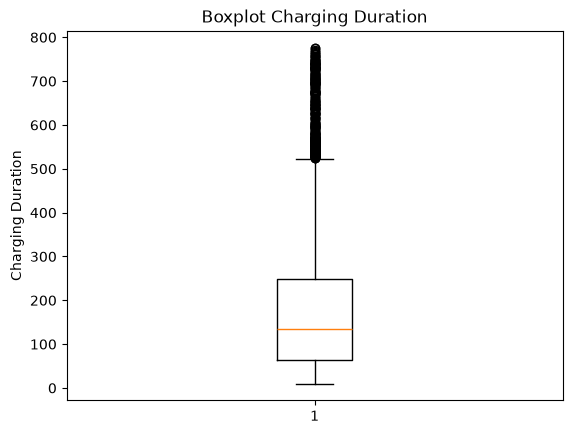

Interpretasi: Boxplot menunjukkan median, penyebaran, serta kemungkinan adanya nilai pencilan pada durasi pengisian.
Titik yang berada jauh dari rentang utama data dapat menunjukkan adanya durasi pengisian yang tidak umum.


In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["energy_consumed_kWh"], bins=20)
plt.title("Sebaran Energy Consumed")
plt.xlabel("Energy Consumed")
plt.ylabel("Frekuensi")
plt.show()
print("Interpretasi: Grafik menunjukkan distribusi jumlah energi yang digunakan oleh kendaraan listrik selama proses pengisian.")
print("Semakin tinggi frekuensi pada suatu rentang, semakin banyak kendaraan yang menggunakan energi pada rentang tersebut.")

plt.hist(df["charging_duration"], bins=20)
plt.title("Sebaran Charging Duration")
plt.xlabel("Charging Duration")
plt.ylabel("Frekuensi")
plt.show()
print("Interpretasi: Grafik menunjukkan distribusi lama waktu yang dibutuhkan kendaraan untuk melakukan pengisian.")
print("Rentang dengan frekuensi tertinggi menunjukkan durasi pengisian yang paling sering terjadi.")

plt.boxplot(df["charging_duration"])
plt.title("Boxplot Charging Duration")
plt.ylabel("Charging Duration")
plt.show()
print("Interpretasi: Boxplot menunjukkan median, penyebaran, serta kemungkinan adanya nilai pencilan pada durasi pengisian.")
print("Titik yang berada jauh dari rentang utama data dapat menunjukkan adanya durasi pengisian yang tidak umum.")



In [6]:
print("***********************KESIMPULAN************************")
print()

print("1. Jawaban pertanyaan analisis")
print("- Rata-rata energi yang digunakan untuk mengisi kendaraan listrik adalah 38.42 kWh.")
print("- Rata-rata waktu tunggu kendaraan sebelum melakukan pengisian adalah 10.22 menit.")
print("- Kondisi lalu lintas yang paling sering terjadi saat kendaraan melakukan pengisian adalah Low, dengan persentase 37.51%.")
print()

print("2. Temuan menarik")
print("- Rata-rata energi yang digunakan dalam satu sesi pengisian adalah 38.42 kWh.")
print("- Rata-rata waktu tunggu kendaraan relatif 10.22 menit, dengan rentang 0–22 menit pada 200 data yang dianalisis.")
print("- Kondisi lalu lintas Low merupakan kategori yang paling sering muncul, yaitu 37.51%, tetapi persentasenya sangat dekat dengan kategori High, yaitu 37.49%.")
print("- Rata-rata durasi pengisian adalah 181.79 menit, dengan nilai maksimum mencapai 766.61 menit, sehingga terdapat variasi durasi pengisian yang cukup besar.")
print("- Kapasitas baterai rata-rata kendaraan adalah 59.35 kWh, dengan kapasitas berkisar antara 30–100 kWh.")
print()

print("3. Keterbatasan data")
print("- Analisis pada bagian statistik deskriptif menggunakan 200 baris data pertama, meskipun dataset secara keseluruhan memiliki 8.354 baris.")
print("- Analisis visualisasi belum dapat digunakan secara lengkap karena terdapat bagian kode yang masih menggunakan variabel df_sample yang belum didefinisikan.")
print("- Analisis yang dilakukan masih berupa statistik deskriptif sehingga belum menjelaskan hubungan sebab-akibat antarvariabel.")
print()

print("4. Pertanyaan lanjutan")
print("- Apakah kepadatan lalu lintas berhubungan dengan waktu tunggu kendaraan?")
print("- Apakah kapasitas baterai berhubungan dengan lama waktu pengisian?")
print("- Apakah energi yang digunakan berbeda berdasarkan jenis kendaraan?")
print("- Apakah waktu pengisian berbeda berdasarkan kondisi lalu lintas?")

***********************KESIMPULAN************************

1. Jawaban pertanyaan analisis
- Rata-rata energi yang digunakan untuk mengisi kendaraan listrik adalah 38.42 kWh.
- Rata-rata waktu tunggu kendaraan sebelum melakukan pengisian adalah 10.22 menit.
- Kondisi lalu lintas yang paling sering terjadi saat kendaraan melakukan pengisian adalah Low, dengan persentase 37.51%.

2. Temuan menarik
- Rata-rata energi yang digunakan dalam satu sesi pengisian adalah 38.42 kWh.
- Rata-rata waktu tunggu kendaraan relatif 10.22 menit, dengan rentang 0–22 menit pada 200 data yang dianalisis.
- Kondisi lalu lintas Low merupakan kategori yang paling sering muncul, yaitu 37.51%, tetapi persentasenya sangat dekat dengan kategori High, yaitu 37.49%.
- Rata-rata durasi pengisian adalah 181.79 menit, dengan nilai maksimum mencapai 766.61 menit, sehingga terdapat variasi durasi pengisian yang cukup besar.
- Kapasitas baterai rata-rata kendaraan adalah 59.35 kWh, dengan kapasitas berkisar antara 30–100 k